In [1]:
#importing libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [2]:
#loading the dataset
df = pd.read_csv(
    "urlset.csv",
    encoding="latin1",
    on_bad_lines="skip"
)

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (96005, 14)

First 5 rows:
                                              domain   ranking mld_res  \
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...  10000000     1.0   
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...  10000000     0.0   
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....  10000000     0.0   
3  mail.printakid.com/www.online.americanexpress....  10000000     0.0   
4  thewhiskeydregs.com/wp-content/themes/widescre...  10000000     0.0   

  mld.ps_res  card_rem  ratio_Rrem  ratio_Arem  jaccard_RR  jaccard_RA  \
0        0.0      18.0  107.611111  107.277778         0.0         0.0   
1        0.0      11.0  150.636364  152.272727         0.0         0.0   
2        0.0      14.0   73.500000   72.642857         0.0         0.0   
3        0.0       6.0  562.000000  590.666667         0.0         0.0   
4        0.0       8.0   29.000000   24.125000         0.0         0.0   

   jaccard_AR  jaccard_AA jaccard_ARrd jaccard_ARrem  label  
0     

C:\Users\sanni\AppData\Local\Temp\ipykernel_17392\3271086400.py:2: DtypeWarning: Columns (0: ranking, 1: mld_res, 2: mld.ps_res, 3: jaccard_ARrd, 4: jaccard_ARrem) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [3]:
#cleaning the dataset
# Keep URL column
df = df[["domain"]]

# Remove missing values
df = df.dropna()

# Remove duplicate URLs
df = df.drop_duplicates()

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (96003, 1)


In [4]:
#featture engineering
def extract_url_features(url):

    url = str(url)

    features = {}

    # URL length
    features["url_length"] = len(url)

    # Number of dots
    features["num_dots"] = url.count(".")

    # Number of hyphens
    features["num_hyphens"] = url.count("-")

    # Number of slashes
    features["num_slashes"] = url.count("/")

    # Number of digits
    features["num_digits"] = sum(
        character.isdigit()
        for character in url
    )

    # Number of special characters
    features["num_special_chars"] = len(
        re.findall(r"[^a-zA-Z0-9]", url)
    )

    # @ symbol
    features["num_at"] = url.count("@")

    # IP address detection
    features["has_ip"] = int(
        bool(
            re.search(
                r"(?:\d{1,3}\.){3}\d{1,3}",
                url
            )
        )
    )

    # Question mark
    features["num_question"] = url.count("?")

    # Equal sign
    features["num_equals"] = url.count("=")

    # Ampersand
    features["num_ampersand"] = url.count("&")

    # HTTPS
    features["uses_https"] = int(
        url.lower().startswith("https")
    )

    return pd.Series(features)


In [5]:
#applying feature engineering to the dataset
features = df["domain"].apply(
    extract_url_features
)

print("Extracted URL Features:")
print(features.head())

Extracted URL Features:
   url_length  num_dots  num_hyphens  num_slashes  num_digits  \
0         225         6            4           10          58   
1          81         5            2            4           1   
2         177         7            1           11          47   
3          60         6            0            2           0   
4         116         1            1           10          21   

   num_special_chars  num_at  has_ip  num_question  num_equals  num_ampersand  \
0                 32       0       0             1           4              3   
1                 15       0       0             0           2              1   
2                 19       0       0             0           0              0   
3                  8       0       0             0           0              0   
4                 13       0       0             1           0              0   

   uses_https  
0           0  
1           0  
2           0  
3           0  
4           0  


In [6]:
#creating the Isolation Forest model
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(features)

print("Isolation Forest model trained successfully!")

Isolation Forest model trained successfully!


In [7]:
#predict anomalies
df["anomaly"] = model.predict(features)

df["anomaly_score"] = model.decision_function(
    features
)

df["status"] = df["anomaly"].map({
    1: "Normal",
    -1: "Abnormal"
})

print(df.head())

                                              domain  anomaly  anomaly_score  \
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...       -1      -0.076813   
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...        1       0.076350   
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....        1       0.013269   
3  mail.printakid.com/www.online.americanexpress....        1       0.200874   
4  thewhiskeydregs.com/wp-content/themes/widescre...        1       0.043966   

     status  
0  Abnormal  
1    Normal  
2    Normal  
3    Normal  
4    Normal  


In [8]:
#display abnormal URLs
abnormal_urls = df[
    df["anomaly"] == -1
]

print("Number of abnormal URLs:",
      len(abnormal_urls))

print("\nAbnormal URLs:")

print(
    abnormal_urls[
        ["domain", "anomaly_score", "status"]
    ].head(20)
)

Number of abnormal URLs: 4801

Abnormal URLs:
                                                domain  anomaly_score  \
0    nobell.it/70ffb52d079109dca5664cce6f317373782/...      -0.076813   
9    horizonsgallery.com/js/bin/ssl1/_id/www.paypal...      -0.020313   
31   horizonsgallery.com/js/bin/ssl/_id/www.paypal....      -0.020073   
72   gplayr.com/pub/www.paypal.com/paypal/cgi-bin/w...      -0.017360   
73   'motors.shop.ebay.com-cars-trucks-724527.jnq3....      -0.126964   
118  secure.pay-pal-comfort.de/index.php?cmd=secure...      -0.021452   
119  sz7i.com/paypal.com.au.q/webscr.html?cmd=SignI...      -0.104708   
120  paypal-online.de/index.html?paypal-scure=conne...      -0.031445   
121  secure.pay-pal-comfort.de/index.php?paypal=saf...      -0.002670   
147  cloud-tech.in/img/es/paypalworldwide.INC/cgi-b...      -0.018186   
161  scur.paypal.info.update.65rth46e5rg3w1erf65gwe...      -0.062879   
181  paypal.cgi.bin.get-into.herf.secure.dispatch35...      -0.031340   
185  

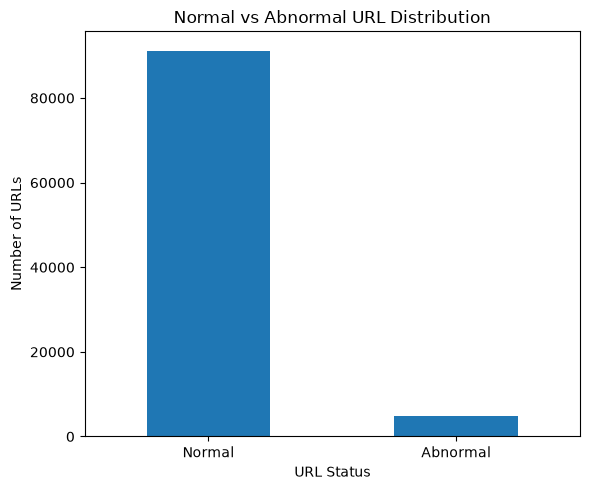

In [9]:
#abnormal distribution visualization
plt.figure(figsize=(6, 5))

df["status"].value_counts().plot(
    kind="bar"
)

plt.title("Normal vs Abnormal URL Distribution")
plt.xlabel("URL Status")
plt.ylabel("Number of URLs")

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

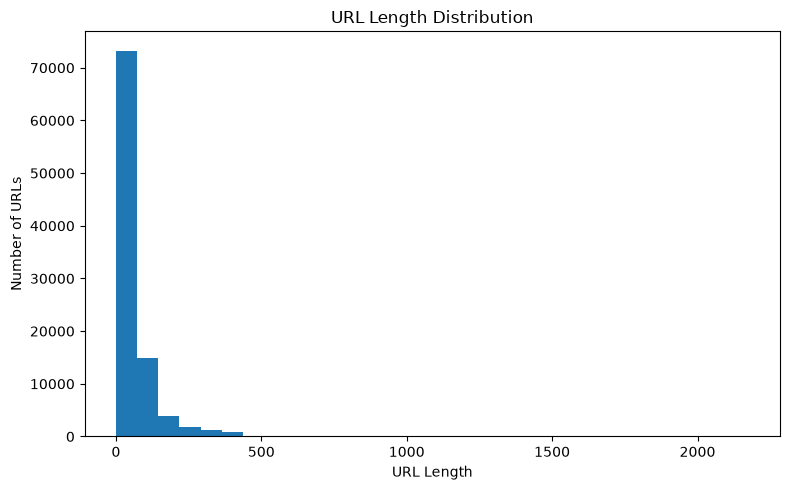

In [10]:
#url length distribution visualization
plt.figure(figsize=(8, 5))

plt.hist(
    features["url_length"],
    bins=30
)

plt.title("URL Length Distribution")
plt.xlabel("URL Length")
plt.ylabel("Number of URLs")

plt.tight_layout()
plt.show()

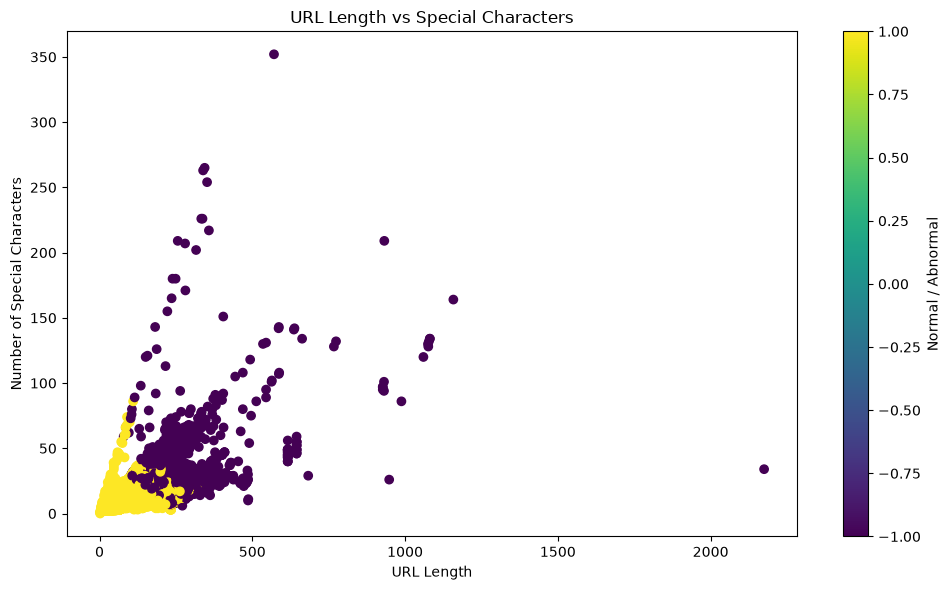

In [11]:
#featuure comparison visualization
plt.figure(figsize=(10, 6))

plt.scatter(
    features["url_length"],
    features["num_special_chars"],
    c=df["anomaly"]
)

plt.title(
    "URL Length vs Special Characters"
)

plt.xlabel("URL Length")
plt.ylabel("Number of Special Characters")

plt.colorbar(
    label="Normal / Abnormal"
)

plt.tight_layout()
plt.show()

In [12]:
#saving the results to a CSV file
df.to_csv(
    "url_anomaly_results.csv",
    index=False
)

print(
    "Anomaly detection results saved successfully!"
)

Anomaly detection results saved successfully!


In [13]:
#testing the model with new URLs
def detect_abnormal_url(url):

    new_features = extract_url_features(url)

    new_features = pd.DataFrame(
        [new_features]
    )

    prediction = model.predict(
        new_features
    )[0]

    score = model.decision_function(
        new_features
    )[0]

    if prediction == -1:
        status = "ABNORMAL"
    else:
        status = "NORMAL"

    print("\nURL:", url)
    print("Status:", status)
    print("Anomaly Score:", round(score, 4))

    return status

In [14]:
detect_abnormal_url(
    "https://www.google.com"
)


URL: https://www.google.com
Status: NORMAL
Anomaly Score: 0.2385


'NORMAL'

In [16]:
detect_abnormal_url(
    "http://192.168.10.25/a-b-c-d/e/f/login.php?user=123&session=456&redirect=true&x=999"
)


URL: http://192.168.10.25/a-b-c-d/e/f/login.php?user=123&session=456&redirect=true&x=999
Status: ABNORMAL
Anomaly Score: -0.037


'ABNORMAL'